### Dependencies

$\text{Generative model}\\[6pt]
s:~\Psi_t = \Psi_{t-1} + \omega \cdot dt, \quad \omega = \dfrac{2 \pi}{24}\\[5pt]
m:~m_t = I_t + \sigma \cdot \sqrt{I_t} \cdot \eta_t\,, \quad where~~I_t=\max[\cos{\Psi_t}, 0]\\[5pt]
$

In [4]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from helper import sigmoid, hill, sm_simulation, phase2sun, SCN_entrain, plot_dynamics, run_1D_sweep, plotting_1D_sweep, run_2D_sweep, plotting_2D_sweep, plotting_2D_sweep_spatial, load_pickles, print_sweep_tree
from helper import run_1D_ensemble, plotting_1D_ensemble, plot_inspection_grid, plot_unwrapped_phase_walk, plot_phase_walk

### Param Sweep

In [2]:
base_config = {
    "N": 100,
    "D": 10,
    "lam": 0.1,
    "gamma": 0.0,
    "mean_period": 23.5,
    "std_period": 0.0,
    "W_prob": 0.2,
    "W_mu": 0.2,
    "W_std": 0,
    "sweep": False,
    "std_phase_noise": 0.05, # 1hr deviation after 24hr
    "std_m_noise": 0.0,
    "dt": 0.1,
    "fastmath": False   #we use strictmath by default
}

$\texttt{- default serious runs:        fastmath=False}\\
\texttt{- huge exploratory scans:      fastmath=True}\\
\texttt{- final / trusted results:     fastmath=False}$

network period: 24.17504051639684
====== SCN TRACKING BENCHMARKS ======
1. Phase-Locking Value (PLV) : 0.8754  (Ideal: 1.0 -> Stable locking)
2. Circular RMSE             : 0.2252 π (Ideal: 0.0 -> Perfect prediction)
3. Period Matching Error     : 0.1750 hr (Ideal: 0.0 -> 24h entrainment)
4. Phase Coherence           : 0.9981  (Ideal: 1.0 -> High precision/unity)


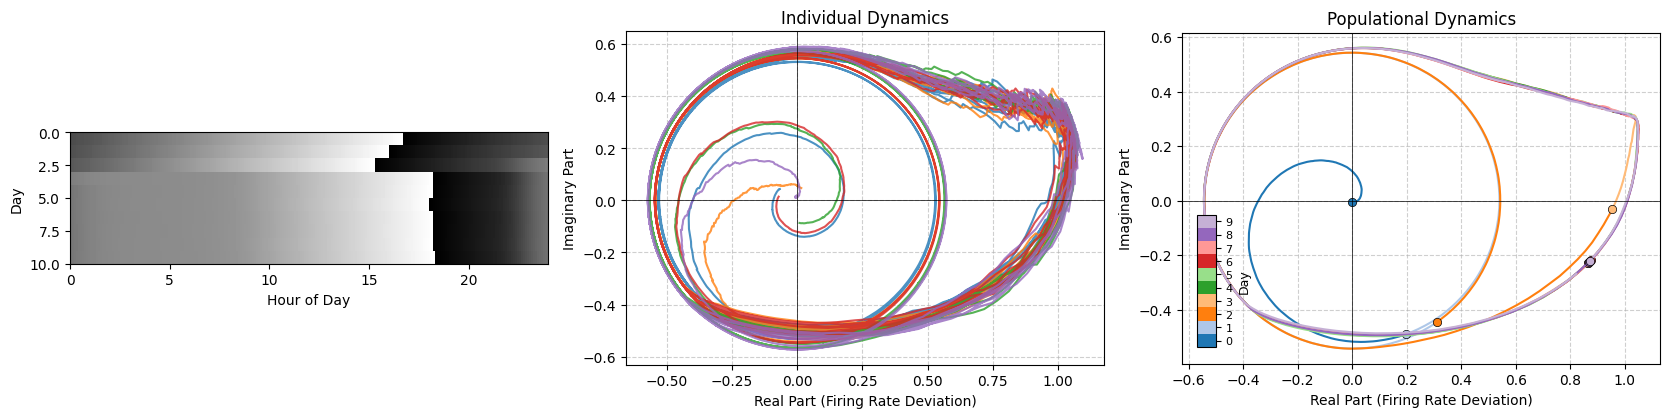

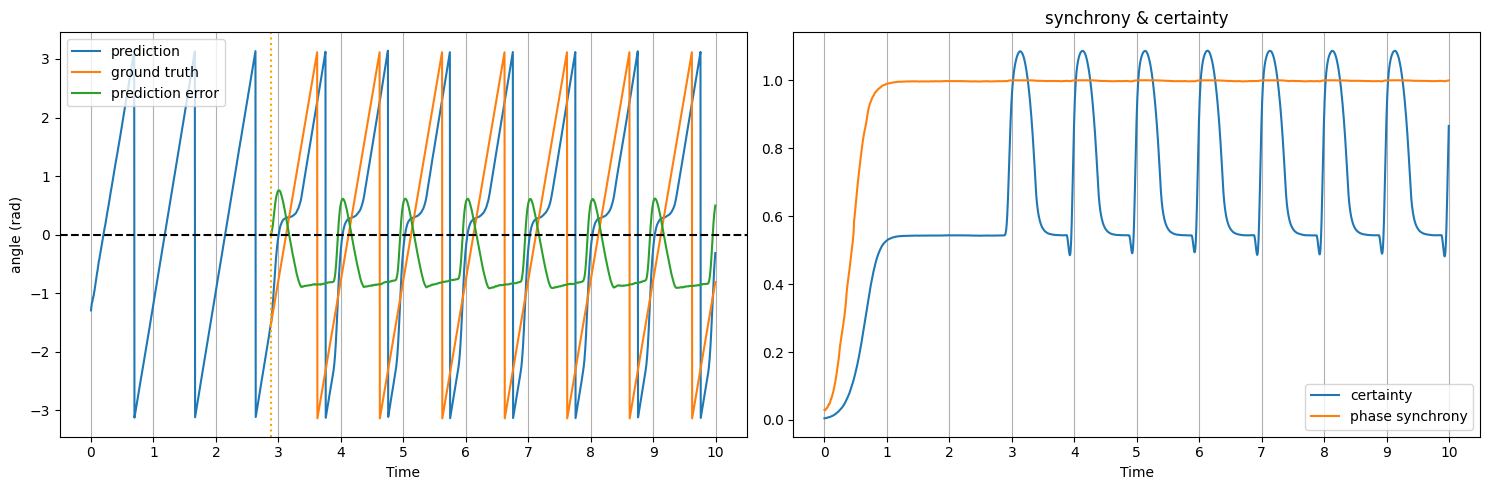

In [55]:
results = SCN_entrain(**{**base_config, "std_period": 0})
plot_dynamics(results);

Macro-state already computed! Loading cached ensemble: 13ec1ee0


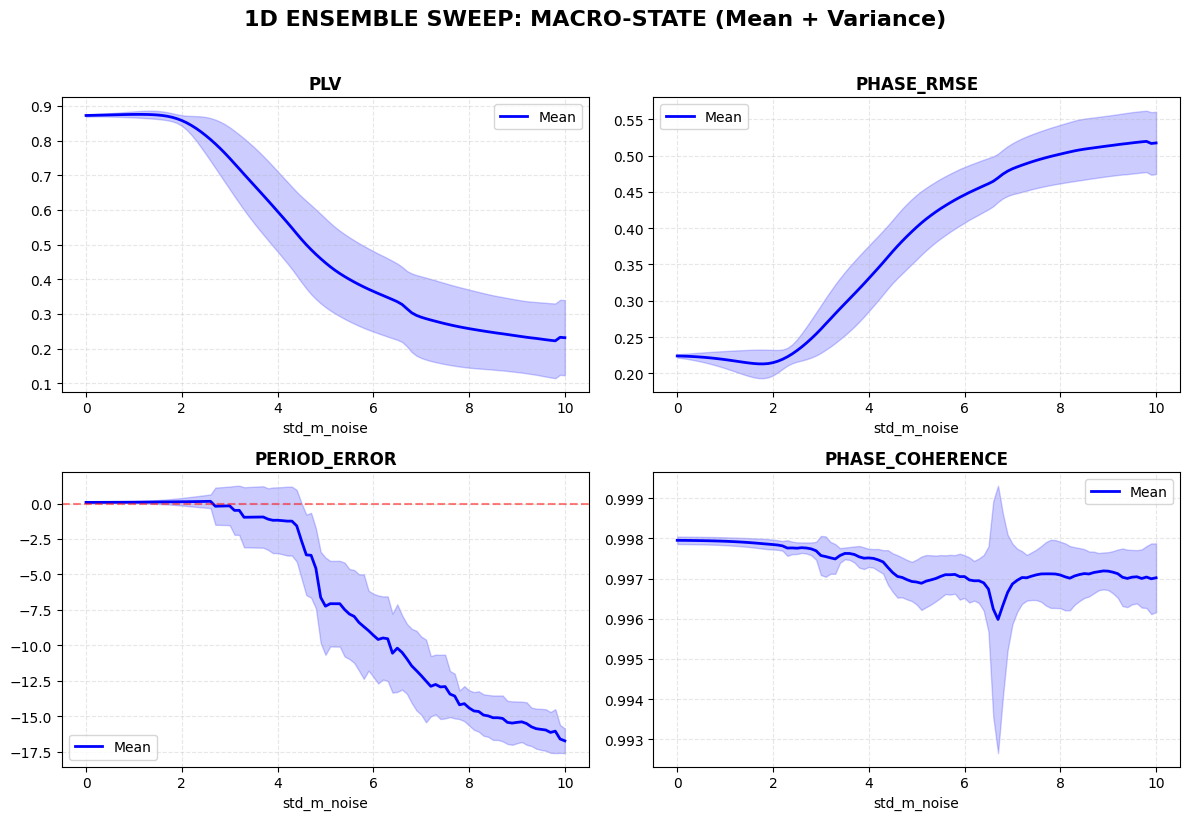

In [10]:
payload = run_1D_ensemble(base_config,
                          sweep_param = 'std_m_noise',
                          sweep_range = np.arange(0, 10.1, 0.1),
                          n_sample = 10,
                          master_seed = 42
                          )
plotting_1D_ensemble(payload, mode='standard');

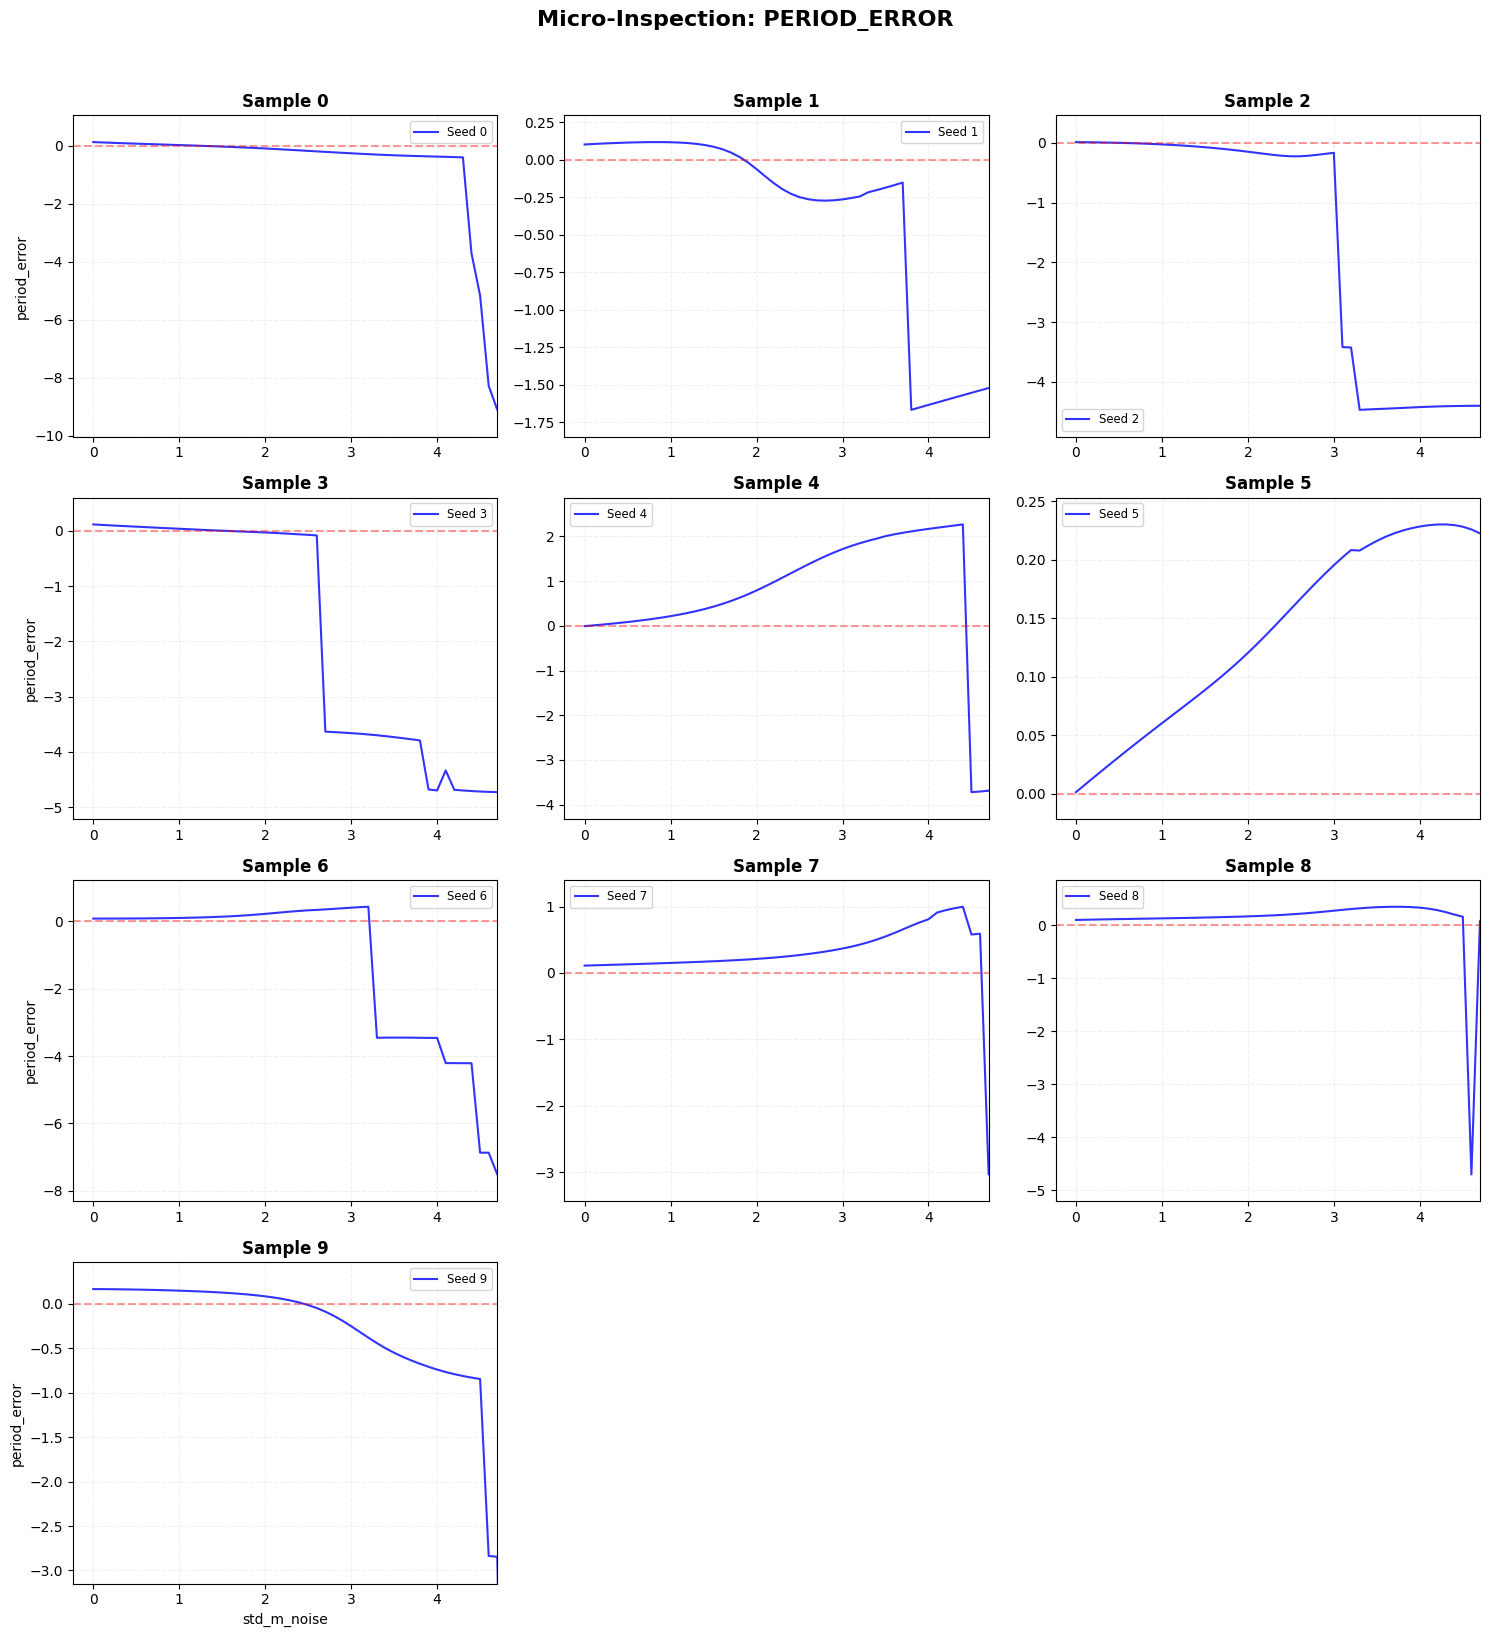

In [ ]:
plot_inspection_grid(payload, target_metric='period_error', xlim=(0,4.7));

 Simulating Sample 4 across 17 values of std_m_noise...


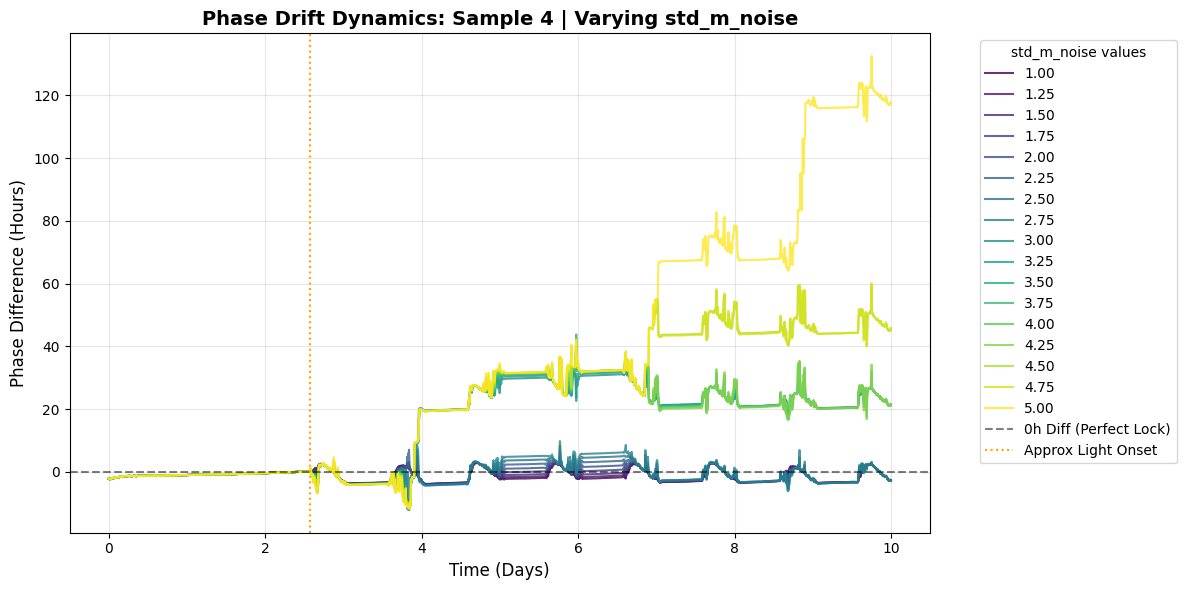

In [17]:
# Pass an array of specific noise values to stack them
plot_phase_walk(base_config, 
                      sweep_param='std_m_noise', 
                      target_values=np.arange(1,5.25,0.25), 
                      sample_id=4);

 Simulating Sample 4 across 1 values of std_m_noise...


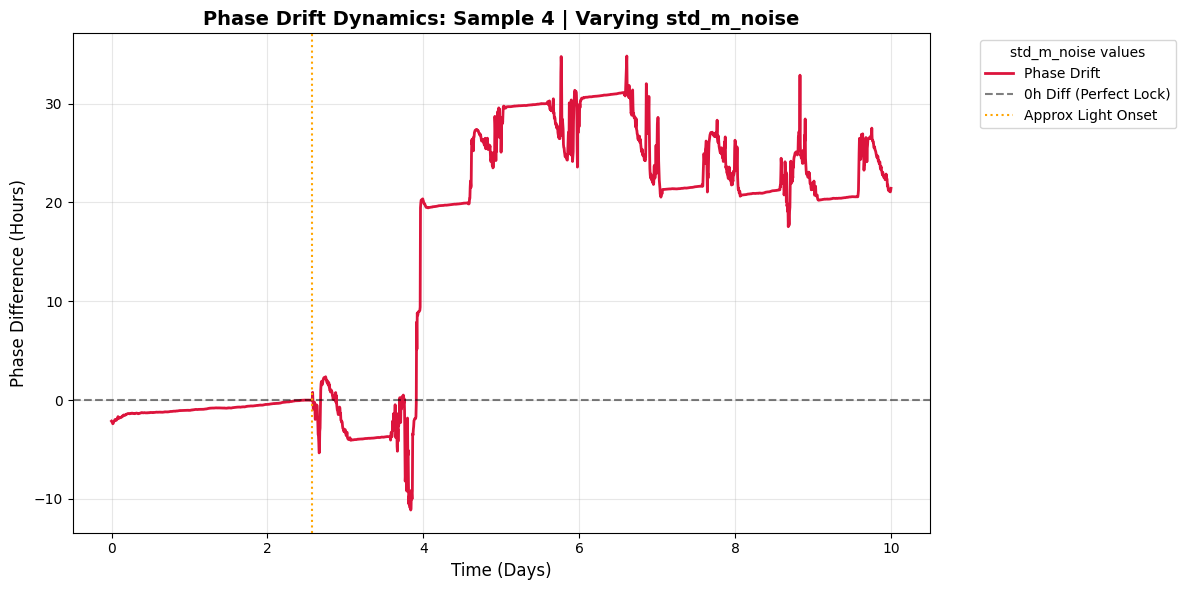

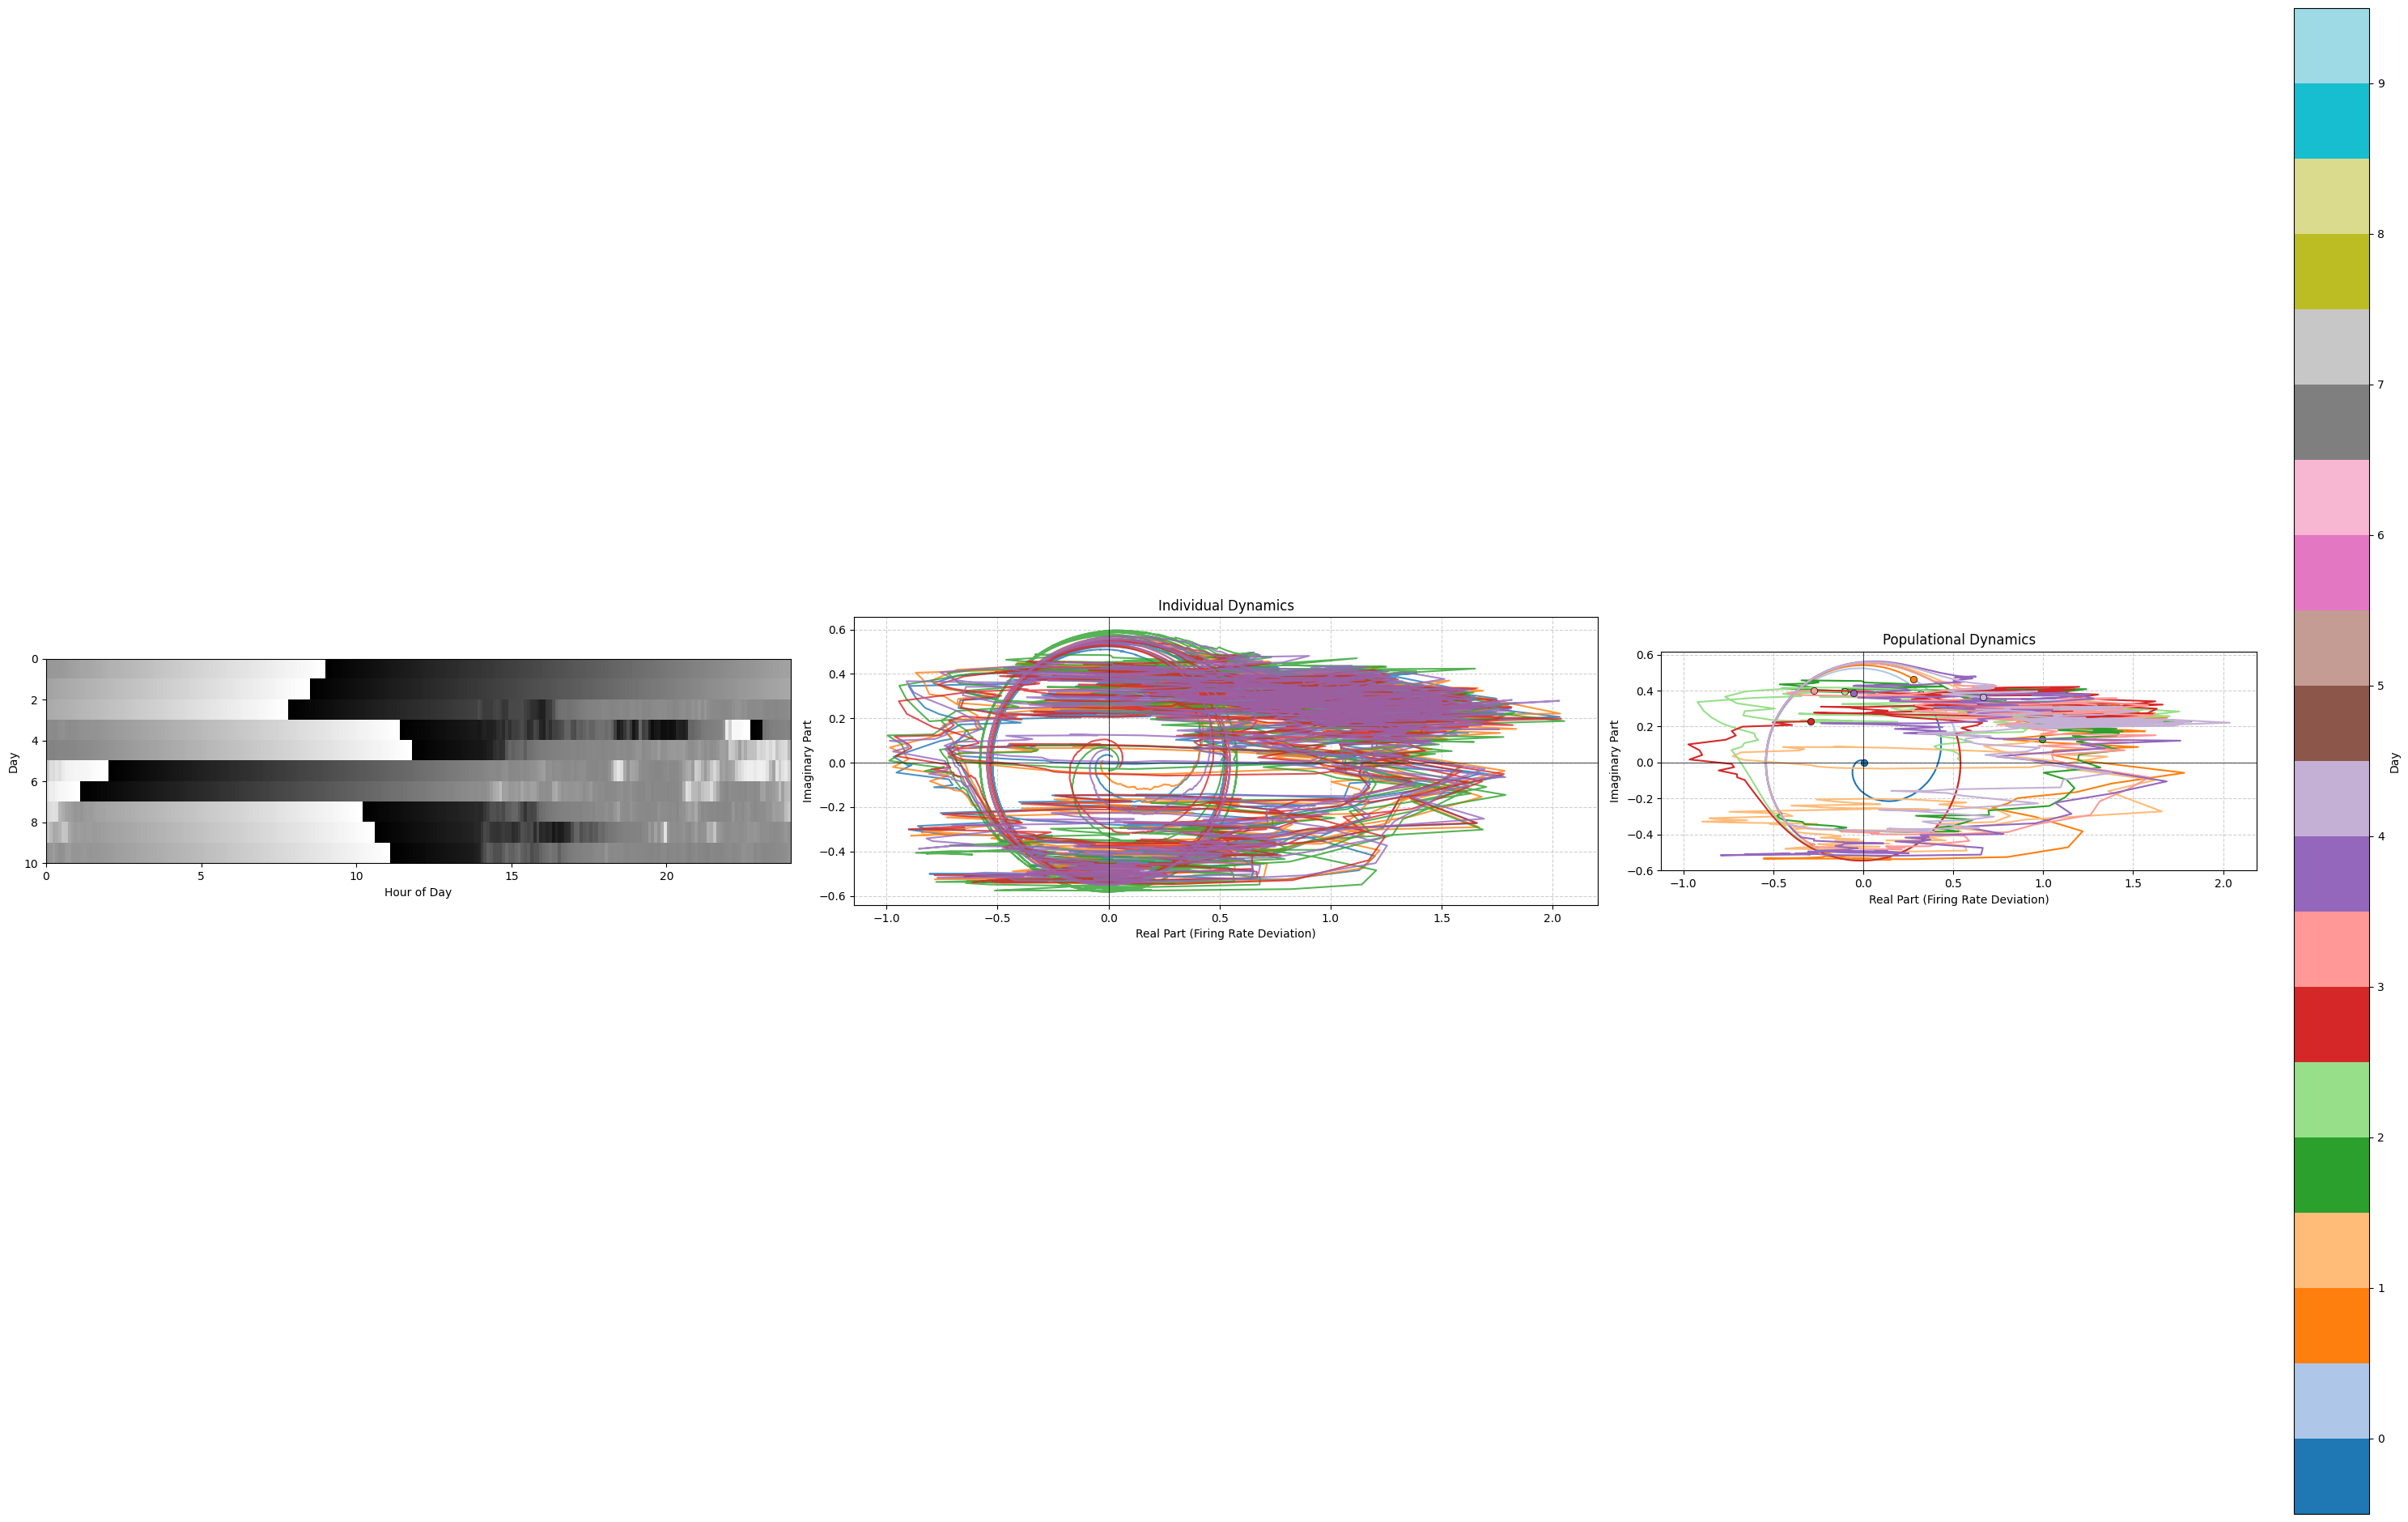

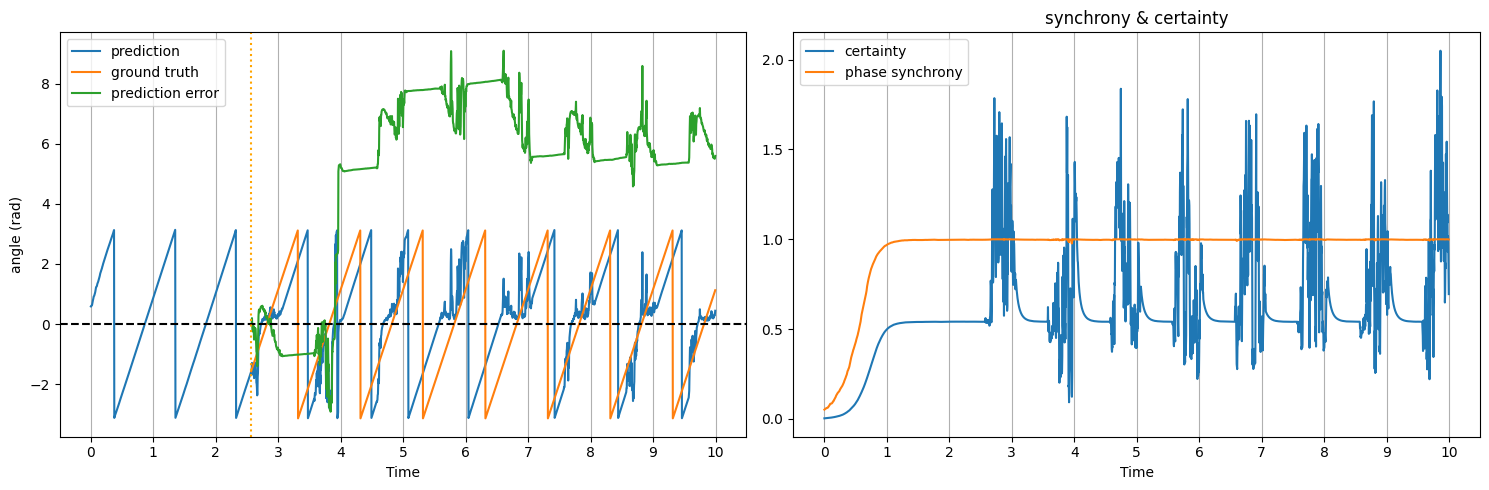

In [18]:
plot_phase_walk(base_config,
                                    sweep_param='std_m_noise', 
                                    target_values=np.arange(3,6,3), 
                                    sample_id=4);

### Main

Population period: 24.04762577689183


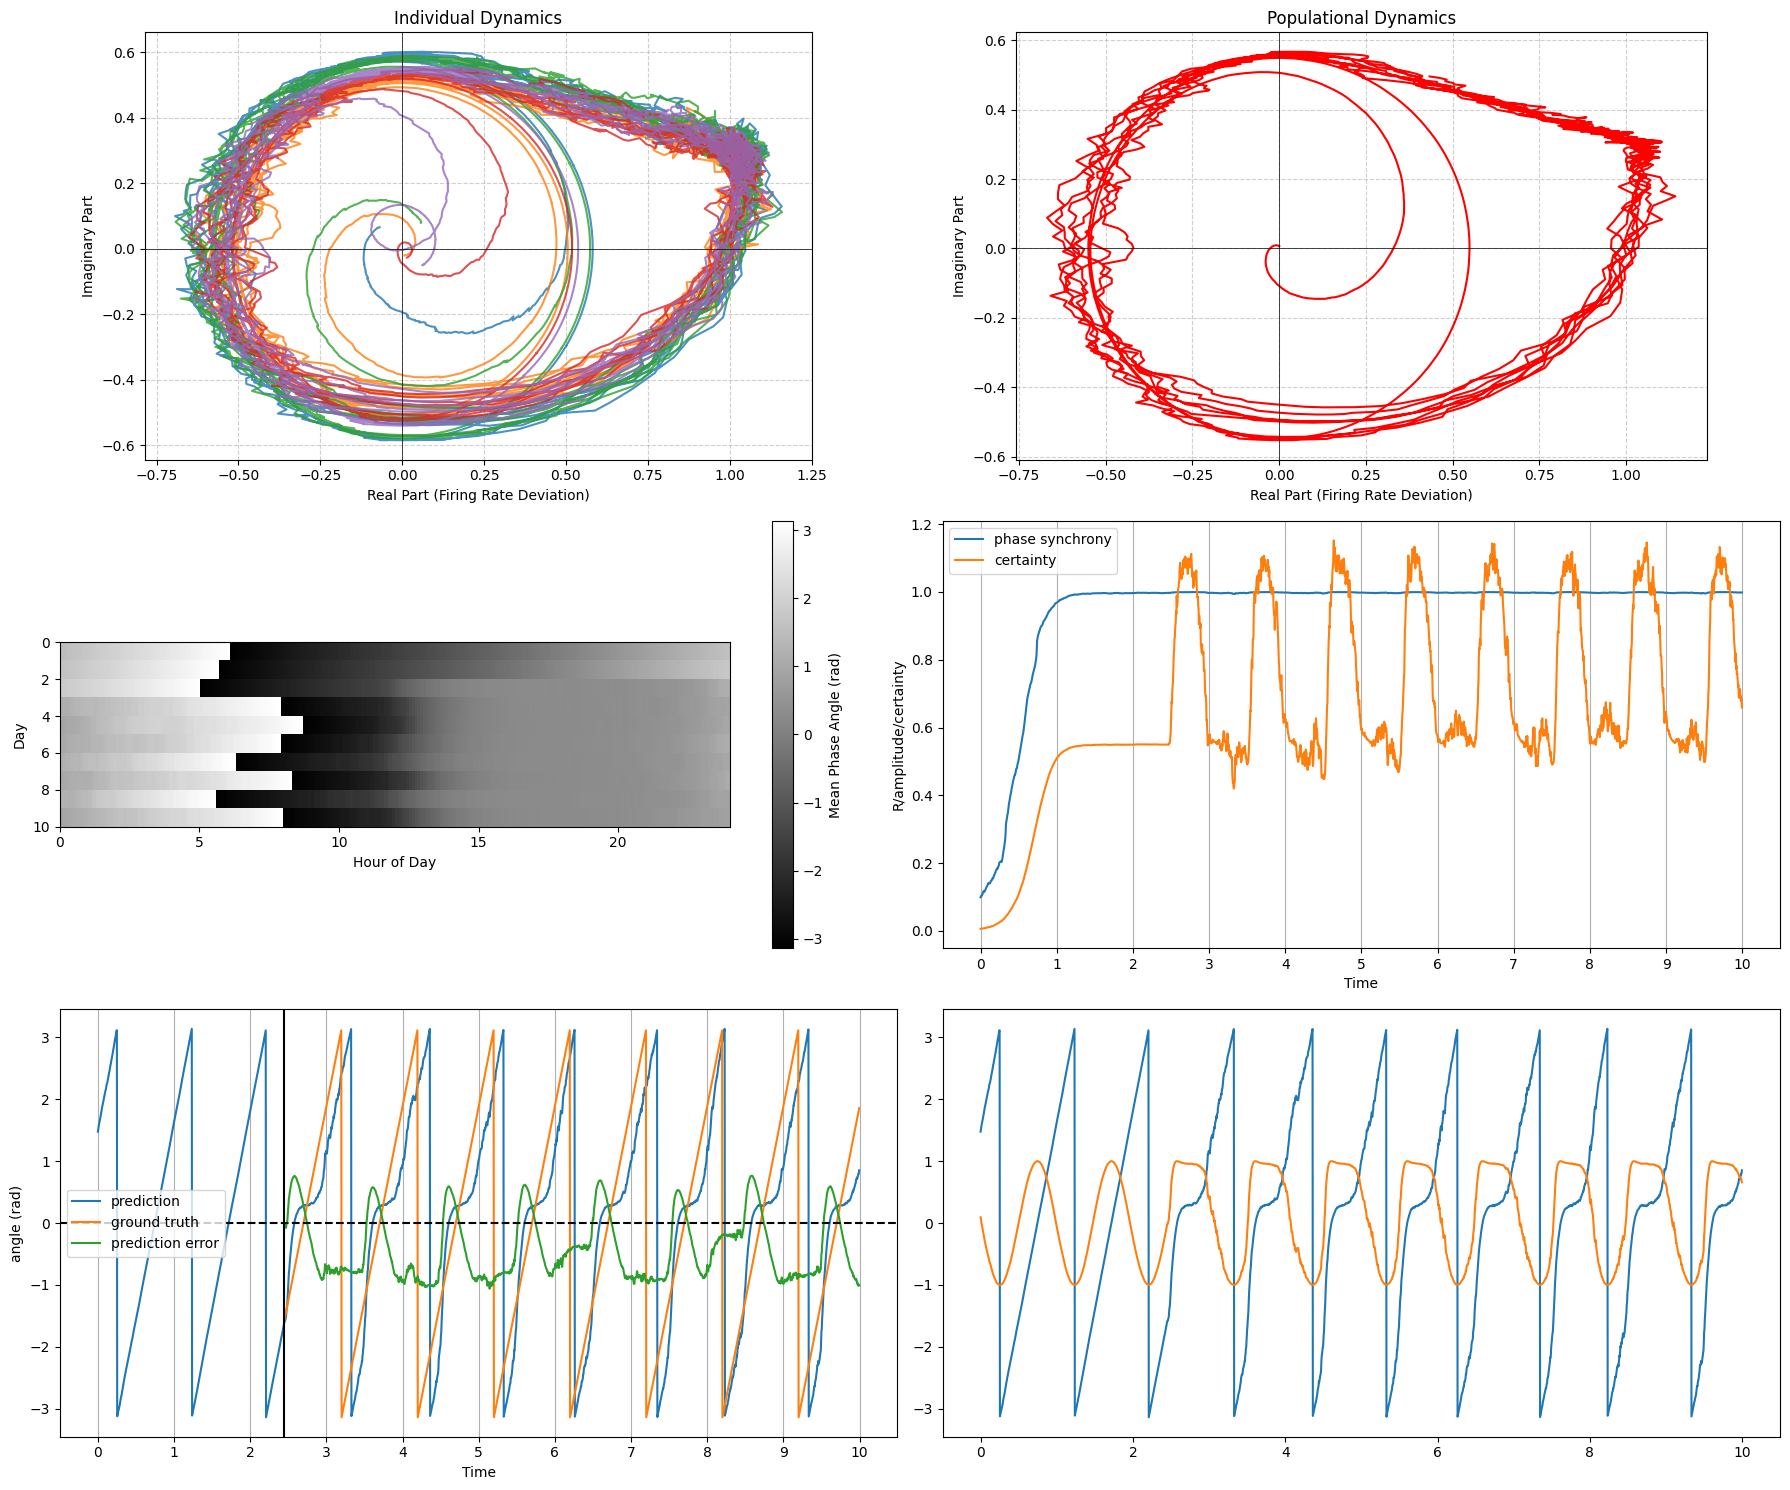

In [29]:
np.random.seed(42)
N = 50                        # Number of neurons
D = 10
T = 24 * D
dt = 0.1 
timesteps = np.arange(0, T, dt)                  # Number of integration steps                 
duration = len(timesteps)


#S-L oscillator parameters
lam = 0.1                     # Linear growth (lambda)
gamma = 0.0                    # Shear/Twist parameter

# Heterogeneous intrinsic frequencies (omega)
mean_period = 23.5
std_period = 0

periods = np.random.normal(loc=mean_period, scale=std_period, size=N)
omegas = 2.0 * np.pi / periods


# Connectome W (N x N)
W_mu = 0.2
W_std = 0
sparsity = 0.2
topology_mask = np.random.rand(N, N) <= sparsity
np.fill_diagonal(topology_mask, 0)
W = np.random.normal(W_mu, W_std, (N,N)) * topology_mask


# External Input Vector I_ext (N,)
# Form: constant drive pulling East (Real axis)
s, m = sm_simulation(D=D, eta=0.2)

I_ext = np.zeros(N, dtype=complex)

light = False

# Initialize state vectors z
amplitudes = np.random.uniform(0.01, 0.1, N)
phases = np.random.uniform(-np.pi, np.pi, N)
z = amplitudes * np.exp(1j*phases)

# Array to store history for plotting
z_history = np.zeros((N, duration), dtype=complex)

# Brownian noise for phases
std_phase = 0.05  # 1hr deviation after 24hr
random_kicks = np.random.normal(size=(N,duration))
phase_noise = std_phase * random_kicks

# ==========================================
# 2. FULLY VECTORIZED INTEGRATION LOOP
# ==========================================
for t in range(duration):

    # Store state
    z_history[:, t] = z


    # --- Deterministic Drift ---
    # prediction
    prediction = (lam + 1j * omegas) * z - (1.0 + 1j * gamma) * (np.abs(z)**2) * z
    
    # update
    update = (1.0 / (N*sparsity)) * (W @ z) 
    
    dz_dt = prediction + update
    
    z = z + (dz_dt * dt) 

    # --- Brownian Diffusion ---
    diffusion = np.exp(1j * phase_noise[:, t] * np.sqrt(dt))
    
    if t < (24*2)/dt:
        z = z * diffusion

    elif t >= (24*2)/dt:
        z_hypothetical = z * diffusion

        if not light:
            rotation = np.exp(1j * np.pi/2)
    
            rotated_history = np.mean(z_history[:, t]) * rotation
            rotated_hypo = np.mean(z_hypothetical) * rotation

            if np.angle(rotated_history) < 0 and np.angle(rotated_hypo) >= 0:
                light=True
                light_onset=t

            else:
                z = z_hypothetical

        if light:
            I_ext[:] = m[t-light_onset] + 0.0j 
            z = (z + I_ext*dt) * diffusion

# ==========================================
# 3. VISUALIZE
# ==========================================

phase_only_vectors = np.exp(1j *np.angle(z_history)) # discard amplitude

R_phase = np.abs(np.mean(phase_only_vectors, axis=0)) 

#population results
mean_field = np.mean(z_history, axis=0)
mf_real = np.real(mean_field)
mf_imag = np.imag(mean_field)
mf_angle = np.angle(mean_field)
mf_amplitude = np.abs(mean_field)

network_frequency, intercept = np.polyfit(timesteps[480:], np.unwrap(mf_angle[480:]), deg=1)
network_period = (2.0 * np.pi) / network_frequency

# Extract Real and Imaginary parts
real_parts = np.real(z_history)
imag_parts = np.imag(z_history)

print(f'Population period: {network_period}')

# Create a 1x2 plot (Complex Plane + Time Series)
fig, axs = plt.subplots(3, 2, figsize=(18, 15))

# Plot 1: Trajectories on the Complex Plane (first 5 neurons)
if N >= 5:
    for i in range(5):
        axs[0,0].plot(real_parts[i, :], imag_parts[i, :], alpha=0.8)
else:
    axs[0,0].plot(real_parts[0, :], imag_parts[0, :], alpha=0.8)
axs[0,0].axhline(0, color='black', linewidth=0.5)
axs[0,0].axvline(0, color='black', linewidth=0.5)
axs[0,0].set_title("Individual Dynamics")
axs[0,0].set_xlabel("Real Part (Firing Rate Deviation)")
axs[0,0].set_ylabel("Imaginary Part")
# axs[0,0].set_xlim(-1, 1)
# axs[0,0].set_ylim(-1, 1)
axs[0,0].grid(True, linestyle='--', alpha=0.6)
axs[0,0].set_aspect('equal')


axs[0,1].plot(mf_real, mf_imag, c='red', linewidth=1.5)
axs[0,1].axhline(0, color='black', linewidth=0.5)
axs[0,1].axvline(0, color='black', linewidth=0.5)
axs[0,1].set_title("Populational Dynamics")
axs[0,1].set_xlabel("Real Part (Firing Rate Deviation)")
axs[0,1].set_ylabel("Imaginary Part")
# axs[0,1].set_xlim(-1, 1)
# axs[0,1].set_ylim(-1, 1)
axs[0,1].grid(True, linestyle='--', alpha=0.6)
axs[0,1].set_aspect('equal')


steps_per_day = int(24 / dt)
psi_2d = mf_angle[:].reshape(D, steps_per_day)

im=axs[1,0].imshow(
    psi_2d,
    aspect=0.66,
    origin='lower',
    extent=[0, 24, 0, D],
    cmap='grey',  # or any other colormap 
    interpolation= 'none'  # or 'none'
)

axs[1,0].invert_yaxis()
axs[1,0].set_xlabel('Hour of Day')
axs[1,0].set_ylabel('Day')
cbar = fig.colorbar(im, ax=axs[1,0], label='Mean Phase Angle (rad)')



axs[1,1].plot(timesteps/24, R_phase, label = 'phase synchrony')
axs[1,1].plot(timesteps/24, mf_amplitude, label = 'certainty')
axs[1,1].set_xticks(range(D+1))
axs[1,1].grid(True, axis="x")
axs[1,1].set_xlabel('Time')
axs[1,1].set_ylabel('R/amplitude/certainty')
axs[1,1].legend()


angular_diff = np.angle(np.exp(1j*(mf_angle[light_onset:] - s[:duration-light_onset])))
axs[2,0].plot(timesteps/24, mf_angle, label = 'prediction')
axs[2,0].plot(timesteps[light_onset:]/24, s[:duration-light_onset], label = 'ground truth')
axs[2,0].plot(timesteps[light_onset:]/24, np.unwrap(angular_diff), label = 'prediction error')
axs[2,0].set_xticks(range(D+1))
axs[2,0].grid(True, axis="x")
axs[2,0].axhline(y=0, c='black', linestyle='--')
axs[2,0].axvline(x=timesteps[light_onset]/24, c='black')
axs[2,0].set_xlabel('Time')
axs[2,0].set_ylabel('angle (rad)')
axs[2,0].legend()

axs[2,1].plot(timesteps/24, mf_angle)
axs[2,1].plot(timesteps/24, np.cos(mf_angle))

plt.tight_layout()
plt.show();

In [30]:
def entrainment_benchmark(z_history, s, timesteps, dt, light_onset, warmup_days=2, target_period=24.0):
    """
    Evaluate how well the simulated SCN tracks the true latent phase.

    Metrics are computed during the STEADY STATE, which begins `warmup_days` 
    after the external drive is turned on (`light_onset`).
    """
    if z_history.ndim != 2:
        raise ValueError("z_history must have shape (N, duration)")
    
    # 1. Extract data when light is on
    # The network experiences light starting from index `light_onset`
    z_light = z_history[:, light_onset:]
    t_light = timesteps[light_onset:]
    
    # The external signal `s` starts its cycle at index 0 from the network's perspective
    light_duration = z_light.shape[1]
    s_light = s[:light_duration]

    # 2. Further extract steady-state 
    warmup_steps = int(round(24.0  * warmup_days / dt))
    if warmup_steps >= light_duration - 2:
        raise ValueError("warmup_days leaves too few samples after light_onset for benchmark evaluation")

    z_light_stdy = z_light[:, warmup_steps:]
    s_light_stdy = s_light[warmup_steps:]
    t_light_stdy = t_light[warmup_steps:]

    # --- Benchmark Calculations (Unchanged) ---
    mean_field = np.mean(z_light_stdy, axis=0)
    mf_angle = np.angle(mean_field)

    phase_diffs = np.angle(np.exp(1j * (mf_angle - s_light_stdy)))
    plv = np.abs(np.mean(np.exp(1j * phase_diffs)))

    rmse = np.sqrt(np.mean(phase_diffs**2))
    rmse = rmse/np.pi

    unwrapped_angle = np.unwrap(mf_angle)
    network_frequency, _ = np.polyfit(t_light_stdy, unwrapped_angle, deg=1)
    if np.abs(network_frequency) < 1e-9:
        network_period = np.nan
        period_error = np.nan
    else:
        network_period = (2.0 * np.pi) / np.abs(network_frequency)
        period_error = np.abs(network_period-target_period)
        period_error_rate = period_error / target_period * 100
    phase_only_vectors = np.exp(1j * np.angle(z_light_stdy))
    phase_coherence = np.mean(np.abs(np.mean(phase_only_vectors, axis=0)))

    return plv, rmse, period_error_rate , phase_coherence, phase_diffs

plv, rmse, period_error_rate, phase_coherence, diff= entrainment_benchmark(z_history, s, timesteps, dt, light_onset)

print("====== SCN TRACKING BENCHMARKS ======")
print(f"1. Phase-Locking Value (PLV) : {plv:.4f}  (Ideal: 1.0 -> Stable locking)")
print(f"2. Circular RMSE             : {rmse:.4f} π (Ideal: 0.0 -> Perfect prediction)")
print(f"3. Period Matching Error     : {period_error_rate:.4f} % (Ideal: 0.0 -> 24h entrainment)")
print(f"4. Phase Coherence           : {phase_coherence:.4f}  (Ideal: 1.0 -> High precision/unity)")
print("=====================================")

====== SCN TRACKING BENCHMARKS ======
1. Phase-Locking Value (PLV) : 0.8714  (Ideal: 1.0 -> Stable locking)
2. Circular RMSE             : 0.2044 π (Ideal: 0.0 -> Perfect prediction)
3. Period Matching Error     : 0.0258 % (Ideal: 0.0 -> 24h entrainment)
4. Phase Coherence           : 0.9981  (Ideal: 1.0 -> High precision/unity)


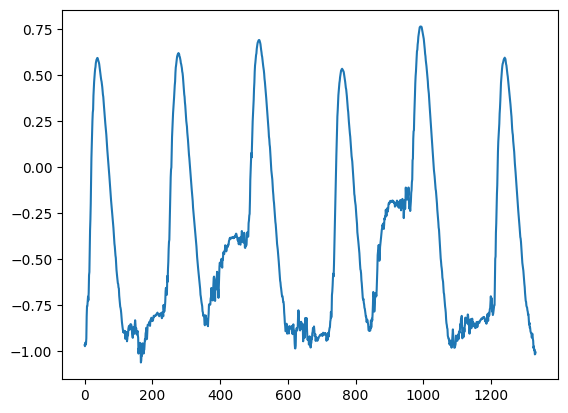

In [31]:
plt.plot(diff)